In [ ]:

!nvidia-smi
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Mon May 11 14:41:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# ==============================================================================
# CELL 1: Setup Environment and Mount Google Drive
# ==============================================================================
!pip install -q ultralytics

from google.colab import drive
import os
from ultralytics import YOLO

# Mount Google Drive to save our weights permanently
drive.mount('/content/drive')

# Define permanent paths in your Drive
PROJECT_DIR = '/content/drive/MyDrive/Smart_Scan/Detection_Model'
DATASET_DIR = os.path.join(PROJECT_DIR, 'dataset')  # Singular: dataset folder
RUNS_DIR = os.path.join(PROJECT_DIR, 'yolo_runs')

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)

print(f"✅ Environment ready. Saving weights to: {RUNS_DIR}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
✅ Environment ready. Saving weights to: /content/drive/MyDrive/Smart_Scan/Detection_Model/yolo_runs


In [ ]:
import os, shutil, yaml, glob
from pathlib import Path

# ==============================================================================
# CELL 2 v3: IBEM → YOLO (FIXED - percentages, 2 classes)
# Format: x_rel  y_rel  width  height  class  (all as % of image, 0-100)
# Classes: 0=embedded (inline math), 1=isolated (display/block math)
# ==============================================================================

EXTRACT_PATH = os.path.join(DATASET_DIR, 'IBEM_data')
LOCAL_EXTRACT = '/content/IBEM_data'
LOCAL_YOLO    = '/content/IBEM_yolo_v2'        # new clean folder
DRIVE_YOLO    = os.path.join(DATASET_DIR, 'IBEM_yolo_v2')

# ── Step 1: Copy from Drive → /content/ if needed ────────────────────────────
if not os.path.exists(LOCAL_EXTRACT) or len(os.listdir(LOCAL_EXTRACT)) == 0:
    print("⚡ Copying IBEM_data from Drive → /content/...")
    shutil.copytree(EXTRACT_PATH, LOCAL_EXTRACT)
    print("✅ Done.")
else:
    print("✅ /content/IBEM_data already exists.")

# ── Step 2: Group Tr*/Va*/Ts* folders ─────────────────────────────────────────
split_map = {}
for folder in sorted(os.listdir(LOCAL_EXTRACT)):
    fpath = os.path.join(LOCAL_EXTRACT, folder)
    if not os.path.isdir(fpath):
        continue
    if folder.startswith('Tr'):
        split_map.setdefault('train', []).append(fpath)
    elif folder.startswith('Va'):
        split_map.setdefault('val', []).append(fpath)
    elif folder.startswith('Ts'):
        split_map.setdefault('test', []).append(fpath)

for split, folders in split_map.items():
    print(f"   {split}: {[os.path.basename(f) for f in folders]}")

# ── Step 3: Create YOLO dirs ──────────────────────────────────────────────────
if os.path.exists(LOCAL_YOLO):
    shutil.rmtree(LOCAL_YOLO)     # clean slate
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(LOCAL_YOLO, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(LOCAL_YOLO, 'labels', split), exist_ok=True)

# ── Step 4: Converter (FIXED) ─────────────────────────────────────────────────
def ibem_to_yolo(txt_path):
    """
    IBEM format (already percentage-based, 0-100):
      x_rel   y_rel   width   height   class
    where x_rel,y_rel = top-left corner as % of image dimensions.

    YOLO format (0-1):
      class  x_center  y_center  width  height
    """
    yolo_lines = []
    with open(txt_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue                        # skip comment/empty lines
            parts = line.split()
            if len(parts) < 4:
                continue
            try:
                x_rel   = float(parts[0])       # top-left x (%)
                y_rel   = float(parts[1])        # top-left y (%)
                w_pct   = float(parts[2])        # width (%)
                h_pct   = float(parts[3])        # height (%)
                cls     = int(float(parts[4])) if len(parts) >= 5 else 0

                # Convert percentage → YOLO normalized (0-1)
                x_c = (x_rel + w_pct / 2) / 100.0
                y_c = (y_rel + h_pct / 2) / 100.0
                w   = w_pct  / 100.0
                h   = h_pct  / 100.0

                # Clamp to [0, 1]
                x_c = max(0.0, min(1.0, x_c))
                y_c = max(0.0, min(1.0, y_c))
                w   = max(0.001, min(1.0, w))
                h   = max(0.001, min(1.0, h))

                yolo_lines.append(f"{cls} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")
            except (ValueError, IndexError):
                continue
    return yolo_lines

# ── Step 5: Convert all ───────────────────────────────────────────────────────
counters  = {'train': 0, 'val': 0, 'test': 0}
total_boxes = {'train': 0, 'val': 0, 'test': 0}
no_annot  = 0

print("\n⚙️  Converting with FIXED format...")
for split, folders in split_map.items():
    for folder in folders:
        for jpg_path in glob.glob(os.path.join(folder, '*.jpg')):
            base = os.path.splitext(os.path.basename(jpg_path))[0]

            # Match paired txt: same base name OR color_ variant
            txt_path = os.path.join(folder, base + '.txt')
            if not os.path.exists(txt_path):
                alt = os.path.join(folder, base.replace('-page', '-color_page') + '.txt')
                txt_path = alt if os.path.exists(alt) else None

            # Copy image
            dst_img = os.path.join(LOCAL_YOLO, 'images', split, os.path.basename(jpg_path))
            shutil.copy2(jpg_path, dst_img)

            # Write YOLO label
            dst_lbl = os.path.join(LOCAL_YOLO, 'labels', split, base + '.txt')
            if txt_path:
                lines = ibem_to_yolo(txt_path)
                with open(dst_lbl, 'w') as f:
                    f.write('\n'.join(lines))
                total_boxes[split] += len(lines)
            else:
                open(dst_lbl, 'w').close()
                no_annot += 1

            counters[split] += 1

print(f"\n✅ Conversion results:")
for split in ['train', 'val', 'test']:
    n = counters[split]
    b = total_boxes[split]
    avg = b / n if n > 0 else 0
    print(f"   {split:6s}: {n} images | {b} boxes | {avg:.1f} boxes/image avg")
print(f"   Images with no paired annotation: {no_annot}")

# ── Step 6: Create data.yaml ──────────────────────────────────────────────────
data_yaml_path = os.path.join(LOCAL_YOLO, 'data.yaml')
data_yaml_content = {
    'path':  LOCAL_YOLO,
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    2,                                # 2 classes!
    'names': ['embedded', 'isolated']          # 0=inline, 1=display math
}
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False)

print(f"\n✅ data.yaml → {data_yaml_path}")
print(f"   nc=2, classes: embedded (inline), isolated (display)")

DATA_YAML = data_yaml_path
print(f"\n📍 DATA_YAML = {DATA_YAML}")
print("▶️  Run Cell 3 to retrain with CORRECT annotations!")


⚡ Copying IBEM_data from Drive → /content/...
✅ Done.
   train: ['Tr00', 'Tr01', 'Tr10']
   test: ['Ts00', 'Ts01', 'Ts10', 'Ts11']
   val: ['Va00', 'Va01']

⚙️  Converting with FIXED format...

✅ Conversion results:
   train : 5171 images | 103939 boxes | 20.1 boxes/image avg
   val   : 957 images | 18370 boxes | 19.2 boxes/image avg
   test  : 2144 images | 44383 boxes | 20.7 boxes/image avg
   Images with no paired annotation: 0

✅ data.yaml → /content/IBEM_yolo_v2/data.yaml
   nc=2, classes: embedded (inline), isolated (display)

📍 DATA_YAML = /content/IBEM_yolo_v2/data.yaml
▶️  Run Cell 3 to retrain with CORRECT annotations!


In [ ]:
# ==============================================================================
# CELL 3: Auto-Resume Training Loop (OPTIMIZED FOR A100)
# ==============================================================================
import os
from ultralytics import YOLO

LOCAL_YOLO = '/content/IBEM_yolo_v2'
DATA_YAML  = os.path.join(LOCAL_YOLO, 'data.yaml')

if not os.path.exists(DATA_YAML):
    raise SystemExit("❌ DATA_YAML not found. Run Cell 2 first!")

print(f"✅ DATA_YAML found: {DATA_YAML}")

# Use a new run name to avoid conflicts
RUN_NAME = 'math_detector'
LAST_CHECKPOINT = os.path.join(RUNS_DIR, RUN_NAME, 'weights', 'last.pt')

if os.path.exists(LAST_CHECKPOINT):
    print(f"\n🔄 Resuming from checkpoint: {LAST_CHECKPOINT}")
    model = YOLO(LAST_CHECKPOINT)
    results = model.train(resume=True)
    print("✅ Training resumed and completed!")
else:
    print("\n🚀 Starting fresh training...")

    # UPGRADE 1: Use Small model instead of Nano (much better accuracy)
    model = YOLO('yolov8s.pt')

    results = model.train(
        data=DATA_YAML,
        epochs=100,             # Increased epochs for better learning
        imgsz=640,

        # --- A100 UTILIZATION UPGRADES ---
        batch=128,              # FORCED 128: AutoBatch played it too safe. This will use ~35GB VRAM.
        cache=True,             # Caches images in system RAM (you have 84GB, this makes it SUPER fast)
        workers=16,             # Uses more CPU cores to load data faster
        # ---------------------------------

        project=RUNS_DIR,
        name=RUN_NAME,
        save=True,
        save_period=5,
        device=0,
        exist_ok=True
    )
    print("🎉 Training complete!")


✅ DATA_YAML found: /content/IBEM_yolo_v2/data.yaml

🔄 Resuming from checkpoint: /content/drive/MyDrive/Smart_Scan/Detection_Model/yolo_runs/math_detector/weights/last.pt
WARNING ⚠️ model '/content/drive/MyDrive/Smart_Scan/Detection_Model/yolo_runs/math_detector/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fl

In [ ]:
import os

# Updated to look for the correct folder
MODEL_DIR = os.path.join(RUNS_DIR, 'math_detector')
weights_dir = os.path.join(MODEL_DIR, 'weights')

print("🔍 Verifying training results...\n")

if os.path.exists(weights_dir):
    weights_files = os.listdir(weights_dir)
    print(f"✅ Weights folder: {weights_dir}")

    has_best = 'best.pt' in weights_files
    has_last = 'last.pt' in weights_files
    print(f"\n   best.pt : {'✅' if has_best else '❌'}")
    print(f"   last.pt : {'✅' if has_last else '❌'}")

    if has_best:
        best_path = os.path.join(weights_dir, 'best.pt')
        size_mb = os.path.getsize(best_path) / 1e6
        print(f"\n🎉 best.pt ready! Size: {size_mb:.1f} MB")
        print(f"\n📥 DOWNLOAD COMMAND:")
        print(f"   from google.colab import files")
        print(f"   files.download('{best_path}')")
else:
    print(f"❌ Weights folder not found at: {weights_dir}")


🔍 Verifying training results...

✅ Weights folder: /content/drive/MyDrive/Smart_Scan/Detection_Model/yolo_runs/math_detector/weights

   best.pt : ✅
   last.pt : ✅

🎉 best.pt ready! Size: 22.5 MB

📥 DOWNLOAD COMMAND:
   from google.colab import files
   files.download('/content/drive/MyDrive/Smart_Scan/Detection_Model/yolo_runs/math_detector/weights/best.pt')


Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3140.0±798.0 MB/s, size: 387.3 KB)
val: Scanning /content/IBEM_yolo_v2/labels/val.cache... 957 images, 101 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 957/957 364.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 7.8it/s 7.7s
                   all        957      18370      0.939      0.914      0.952      0.767
              embedded        853      14911      0.891      0.836      0.909      0.663
              isolated        683       3459      0.987      0.993      0.994      0.872
Speed: 0.6ms preprocess, 1.0ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val-3
mAP50-95: 0.7675
mAP50: 0.9516
Precision: 0.9389
Recall: 0.9142


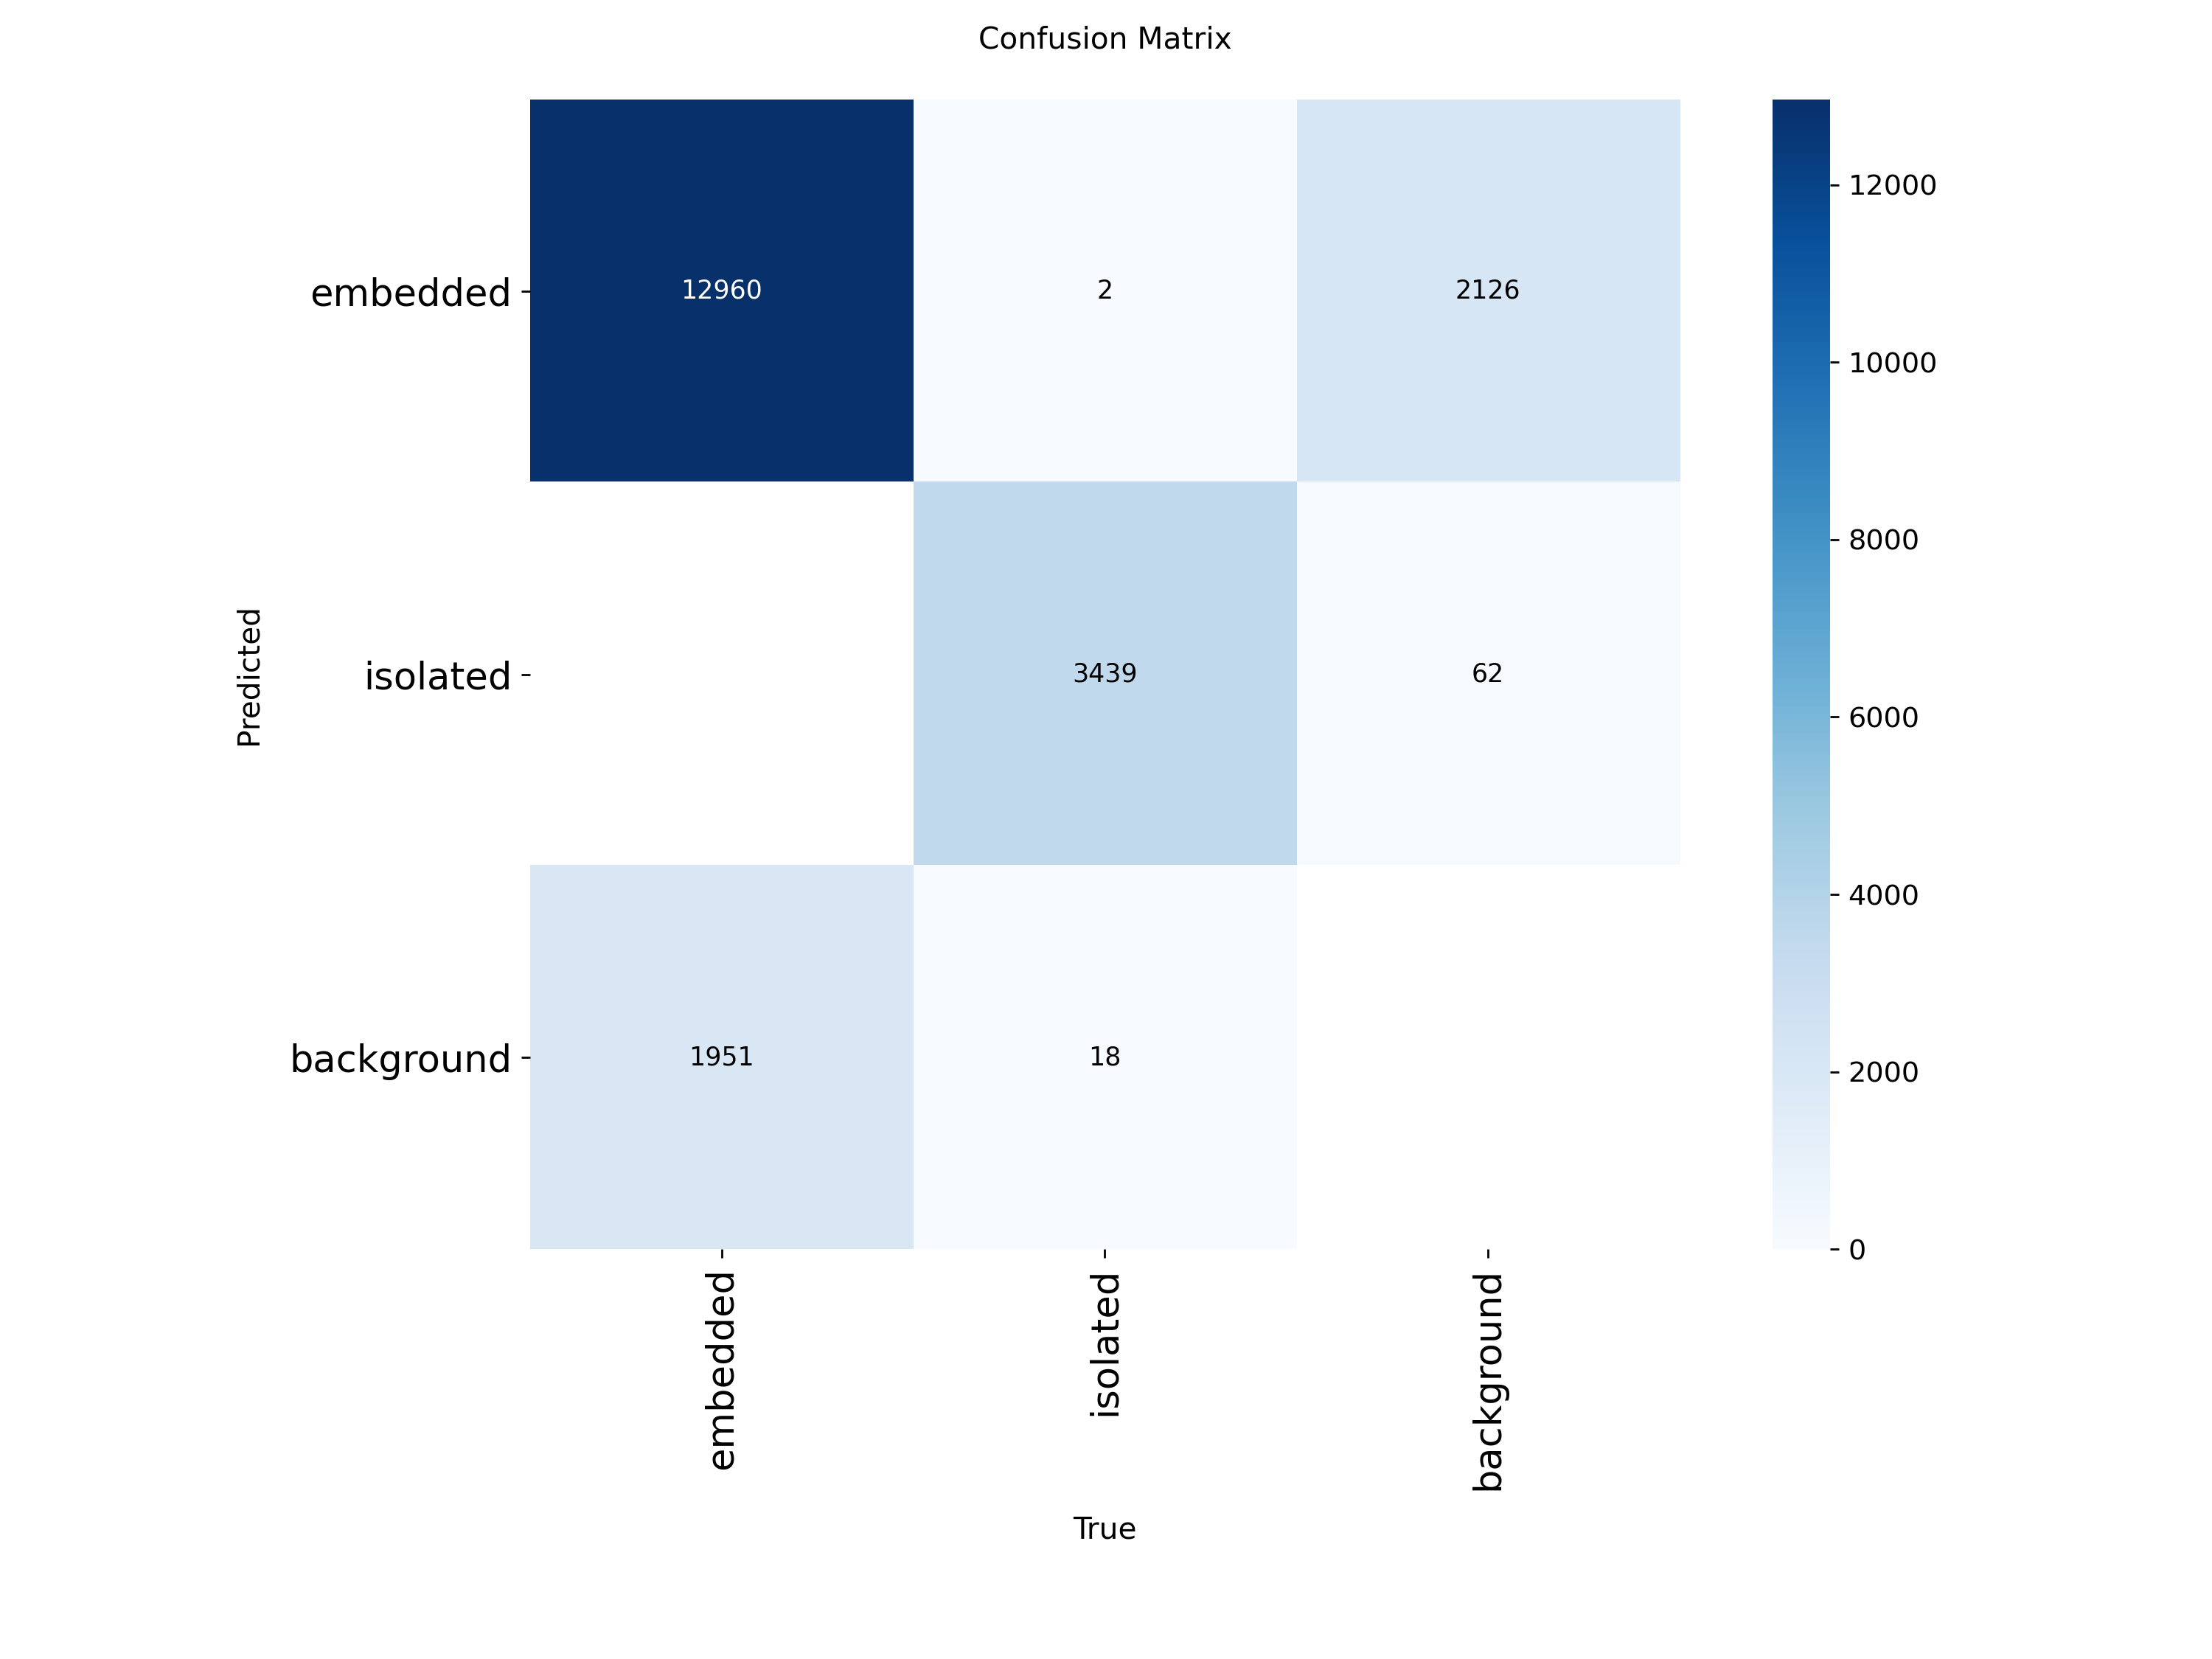

In [ ]:
# Evaluate the model performance on the validation set

from ultralytics import YOLO
import os
from IPython.display import display, Image

# Load the best model from training
best_model_path = "/content/drive/MyDrive/Smart_Scan/Detection_Model/yolo_runs/math_detector/weights/best.pt"
model = YOLO(best_model_path)

# Run validation to check accuracy, mAP, precision, and recall
metrics = model.val()

# Print out key performance metrics
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

# Display some of the generated performance plots (e.g. Confusion Matrix, PR curve)
results_dir = "/content/drive/MyDrive/Smart_Scan/Detection_Model/yolo_runs/math_detector"
if os.path.exists(os.path.join(results_dir, "confusion_matrix.png")):
    display(Image(filename=os.path.join(results_dir, "confusion_matrix.png"), width=600))
if os.path.exists(os.path.join(results_dir, "PR_curve.png")):
    display(Image(filename=os.path.join(results_dir, "PR_curve.png"), width=600))
